In [1]:
# Cell 1 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Cell 2 - Load Dataset

df = pd.read_csv(r"C:\Users\bts\OneDrive\OIBSIP\Task 3\CAR DETAILS FROM CAR DEKHO.csv")

In [3]:
df.columns = [
    "Car_Name",
    "Year",
    "Selling_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner"
]

df.head()

,Car_Name,Year,Selling_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
# Cell 3 - View Dataset

df.head()

,Car_Name,Year,Selling_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:
df.shape

(4340, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Car_Name       4340 non-null   str  
 1   Year           4340 non-null   int64
 2   Selling_Price  4340 non-null   int64
 3   Kms_Driven     4340 non-null   int64
 4   Fuel_Type      4340 non-null   str  
 5   Seller_Type    4340 non-null   str  
 6   Transmission   4340 non-null   str  
 7   Owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 515.2 KB


In [7]:
df.describe()

,Year,Selling_Price,Kms_Driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [8]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [9]:
# Cell 4 - Check Missing Values

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
# Cell 5 - Remove Duplicates

print("Before:", df.shape)

df = df.drop_duplicates()

print("After :", df.shape)

Before: (4340, 8)
After : (3577, 8)


In [11]:
# Cell 6 – Clean Categorical Columns

# Clean categorical columns

categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner"
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

print(df[categorical_columns].head())

  Fuel_Type Seller_Type Transmission         Owner
0    Petrol  Individual       Manual   First Owner
1    Petrol  Individual       Manual   First Owner
2    Diesel  Individual       Manual   First Owner
3    Petrol  Individual       Manual   First Owner
4    Diesel  Individual       Manual  Second Owner


In [12]:
# Cell 7 – Feature Engineering

from datetime import datetime

current_year = datetime.now().year

# Car Age
df["Car_Age"] = current_year - df["Year"]

# Brand Extraction
df["Brand"] = df["Car_Name"].apply(lambda x: x.split()[0])

df.head()

,Car_Name,Year,Selling_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


In [13]:
# Cell 8 - Drop Year

df.drop("Year", axis=1, inplace=True)

In [14]:
# Cell 9 - Dataset Preview

df.head()

,Car_Name,Selling_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,Maruti 800 AC,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


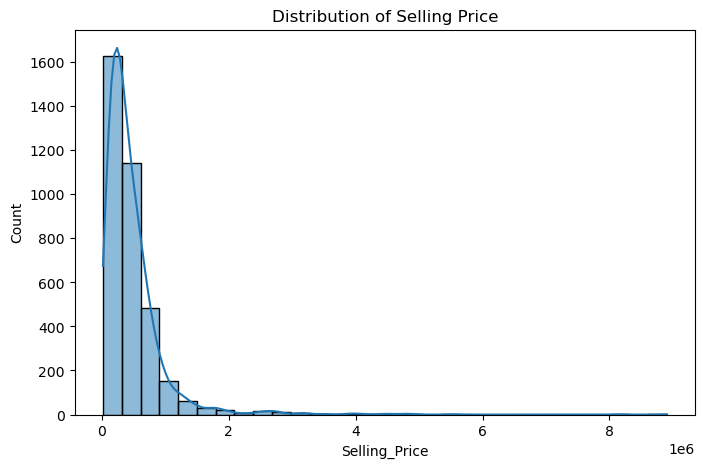

In [15]:
# Cell 10 - Selling Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")

plt.show()

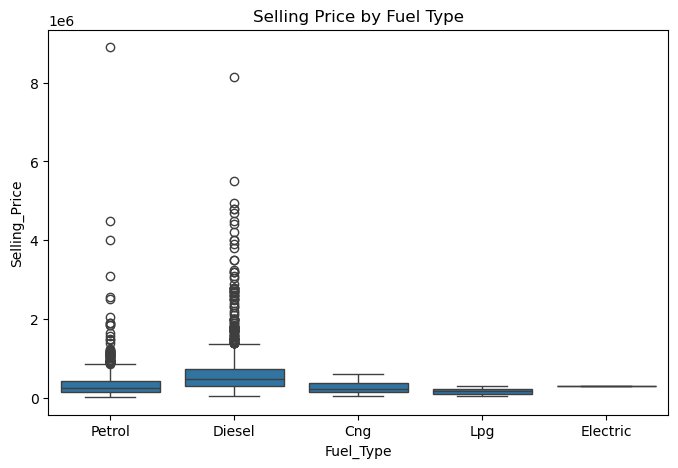

In [16]:
# Cell 11 - Fuel Type vs Selling Price

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price by Fuel Type")

plt.show()

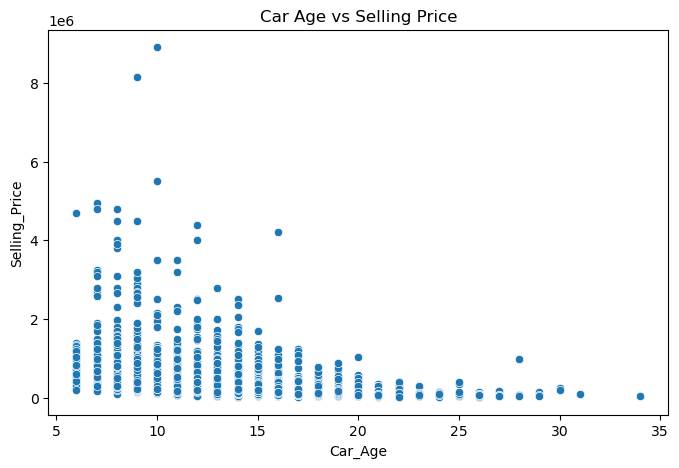

In [17]:
# Cell 12 - Car Age vs Selling Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="Selling_Price",
    data=df
)

plt.title("Car Age vs Selling Price")

plt.show()

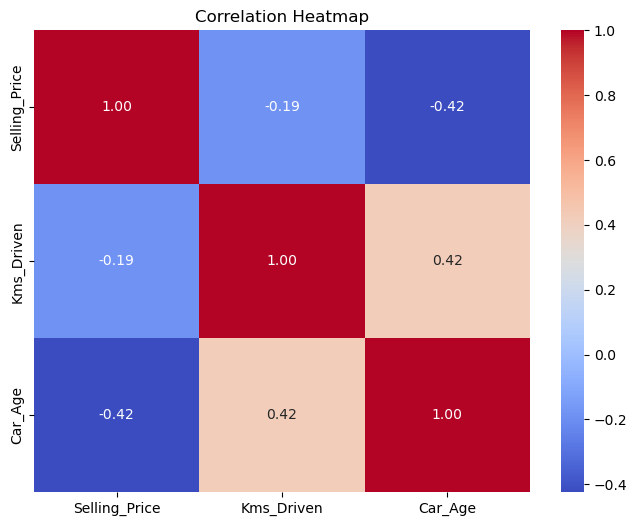

In [20]:
# Cell 13 - Correlation Heatmap

plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
# Cell 14 - Features & Target

X = df.drop(["Selling_Price","Car_Name"], axis=1)

y = df["Selling_Price"]

In [22]:
# Cell 15 - Categorical Features

categorical_features = X.select_dtypes(include="object").columns

categorical_features

Index(['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Brand'], dtype='str')

In [23]:
# Cell 16 - One Hot Encoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [24]:
# Cell 17 - Train Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Cell 18 - Linear Regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

lr_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [26]:
# Cell 19 - Prediction

lr_pred = lr_model.predict(X_test)

In [27]:
# Cell 20 - Evaluation

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,lr_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,lr_pred)))

print("R² :",r2_score(y_test,lr_pred))

Linear Regression
MAE : 206368.40148772032
RMSE : 431734.1054329345
R² : 0.4213752311234885


In [28]:
# Cell 21 - Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [29]:
# Cell 22 - Prediction

rf_pred = rf_model.predict(X_test)

In [30]:
# Cell 23 - Evaluation

print("Random Forest")

print("MAE :",mean_absolute_error(y_test,rf_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,rf_pred)))

print("R² :",r2_score(y_test,rf_pred))

Random Forest
MAE : 158380.94121347804
RMSE : 364008.80346464826
R² : 0.5886721845176794


In [31]:
# Cell 24 - Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingRegressor(
        random_state=42
    ))
])

gb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [32]:
# Cell 25 - Prediction

gb_pred = gb_model.predict(X_test)

In [33]:
# Cell 26 - Evaluation

print("Gradient Boosting")

print("MAE :",mean_absolute_error(y_test,gb_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,gb_pred)))

print("R² :",r2_score(y_test,gb_pred))

Gradient Boosting
MAE : 157021.99269901004
RMSE : 377750.2766031865
R² : 0.5570304363668408


In [34]:
# Cell 27 - Compare Models

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        mean_absolute_error(y_test,lr_pred),
        mean_absolute_error(y_test,rf_pred),
        mean_absolute_error(y_test,gb_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,lr_pred)),
        np.sqrt(mean_squared_error(y_test,rf_pred)),
        np.sqrt(mean_squared_error(y_test,gb_pred))
    ],

    "R2 Score":[
        r2_score(y_test,lr_pred),
        r2_score(y_test,rf_pred),
        r2_score(y_test,gb_pred)
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,206368.401488,431734.105433,0.421375
1,Random Forest,158380.941213,364008.803465,0.588672
2,Gradient Boosting,157021.992699,377750.276603,0.557030


In [35]:
# Cell 28 - Feature Importance

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
42,remainder__Car_Age,0.221186
41,remainder__Kms_Driven,0.132931
7,cat__Transmission_Automatic,0.129063
8,cat__Transmission_Manual,0.118515
1,cat__Fuel_Type_Diesel,0.070895
15,cat__Brand_Audi,0.048344
3,cat__Fuel_Type_Petrol,0.044750
27,cat__Brand_Land,0.040015
38,cat__Brand_Toyota,0.036909
16,cat__Brand_BMW,0.014530


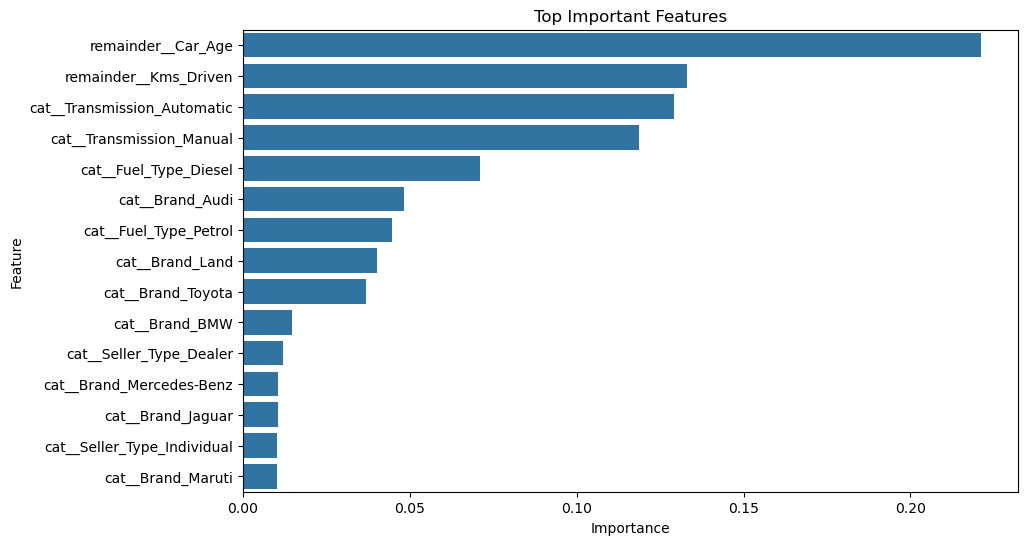

In [36]:
# Cell 29 - Feature Importance Plot

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15)
)

plt.title("Top Important Features")

plt.show()

In [38]:
# Cell 30 - Best Model

best_model = results.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
1,Random Forest,158380.941213,364008.803465,0.588672
2,Gradient Boosting,157021.992699,377750.276603,0.557030
0,Linear Regression,206368.401488,431734.105433,0.421375


In [39]:
print("=" * 70)
print("🎉 CONGRATULATIONS! 🎉")
print("=" * 70)

print("\n✅ OIBSIP Task 3 - Car Price Prediction with Machine Learning")
print("has been completed successfully!")

print("\n📌 Project Summary:")
print("✔ Dataset loaded and cleaned")
print("✔ Missing values and duplicates handled")
print("✔ Feature engineering completed")
print("✔ Exploratory Data Analysis (EDA) performed")
print("✔ Categorical features encoded")
print("✔ Correlation heatmap generated")
print("✔ Data split into training and testing sets")
print("✔ Linear Regression model trained and evaluated")
print("✔ Random Forest Regressor trained and evaluated")
print("✔ Gradient Boosting Regressor trained and evaluated")
print("✔ Models evaluated using MAE, RMSE, and R² Score")
print("✔ Feature importance analyzed")
print("✔ Best-performing model identified")

print("\n🏆 Task Completed Successfully!")
print("Thank you for exploring Machine Learning with Python. 🚀")
print("=" * 70)

🎉 CONGRATULATIONS! 🎉

✅ OIBSIP Task 3 - Car Price Prediction with Machine Learning
has been completed successfully!

📌 Project Summary:
✔ Dataset loaded and cleaned
✔ Missing values and duplicates handled
✔ Feature engineering completed
✔ Exploratory Data Analysis (EDA) performed
✔ Categorical features encoded
✔ Correlation heatmap generated
✔ Data split into training and testing sets
✔ Linear Regression model trained and evaluated
✔ Random Forest Regressor trained and evaluated
✔ Gradient Boosting Regressor trained and evaluated
✔ Models evaluated using MAE, RMSE, and R² Score
✔ Feature importance analyzed
✔ Best-performing model identified

🏆 Task Completed Successfully!
Thank you for exploring Machine Learning with Python. 🚀
